In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import colorednoise as cn
from scipy.signal import find_peaks
from scipy.stats import laplace
from scipy.interpolate import CubicSpline, interp1d

In [2]:
n_probes = 100
n_channels = 64
sim_flag = 'probes_locs'

top_dir = os.path.dirname(os.path.dirname(os.getcwd()))
sim_dir = os.path.join(top_dir, 'models/NEURON/NMLCL000073-NEURON/output/LFP_basal')
sim_label = f'LFP_basal-0nA-50Ex1-1x40Hz-{n_probes}x{n_channels}lp-{sim_flag}'


eap_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-simulated_eaps.pkl')
probe_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-recording_probe_locs.pkl')

In [3]:
data_df = pd.read_pickle(eap_file_path)
probes = np.array(pd.read_pickle(probe_file_path))

In [30]:
num_probes, num_channels, _ = np.shape(probes)

probe_nums = []
channel_nums = []

for i, row in data_df.iterrows():
    probe_nums.append(int(i/num_channels))
    channel_nums.append(i%num_channels)

data_df['probe_num'] = probe_nums
data_df['channel_num'] = channel_nums

In [31]:
data_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4683155998794908e-05, 1.4683033719120108e-0...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7234130407982727e-05, 1.7234009139822218e-0...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.9768643569360802e-05, 1.9768523109521328e-0...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.229151647911385e-05, 2.2291396496642475e-05...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4816832935173393e-05, 2.4816713131216955e-0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


In [32]:
spike_df = data_df.copy()
for i, row in spike_df.iterrows():

    row.t = row.t[1500:2580]
    row.vm = row.vm[1500:2580]
    row.ve = row.ve[1500:2580]

    spike_df.iloc[i] = row

    # spike_df.iloc[i].t = row.t[1500:2580]
    # spike_df.iloc[i].ve = row.ve[1500:2580]

In [33]:
spike_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[550.0000000000565, 550.1000000000565, 550.200...","[-64.7459552843999, -64.73853207623281, -64.73...","[0.0001708876415554942, 0.00017114438828531262...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[550.0000000000565, 550.1000000000565, 550.200...","[-64.7459552843999, -64.73853207623281, -64.73...","[0.00017436095346014336, 0.0001745774218155747...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[550.0000000000565, 550.1000000000565, 550.200...","[-64.7459552843999, -64.73853207623281, -64.73...","[0.00017812560520063216, 0.0001783004890160522...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[550.0000000000565, 550.1000000000565, 550.200...","[-64.7459552843999, -64.73853207623281, -64.73...","[0.00018233239593964723, 0.0001824649711820863...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[550.0000000000565, 550.1000000000565, 550.200...","[-64.7459552843999, -64.73853207623281, -64.73...","[0.000186986539104384, 0.000187075850188031, 0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


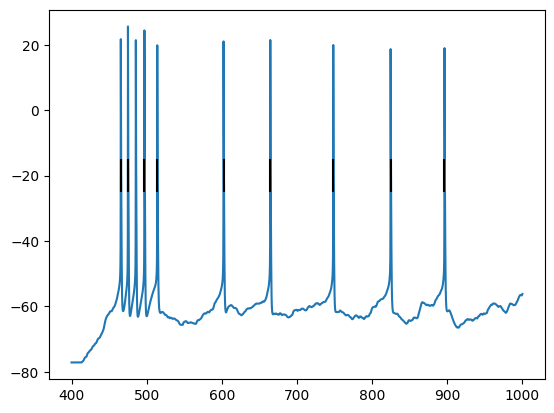

In [61]:
plt.plot(data_df.iloc[0].t, data_df.iloc[0].vm)
all_peaks = find_peaks(data_df.iloc[0].vm, threshold=5)[0]
plt.vlines(data_df.iloc[0].t[all_peaks], -25, -15, color='k')

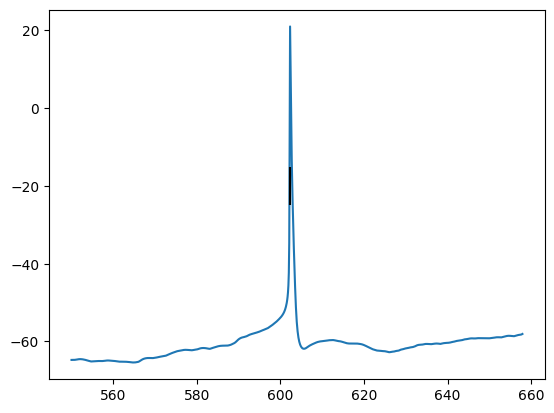

In [55]:
# plt.plot(data_df.iloc[0].t[:-1], data_df.iloc[0].ve)
plt.plot(spike_df.iloc[0].t, spike_df.iloc[0].vm)
all_peaks = find_peaks(spike_df.iloc[0].vm, threshold=5)[0]
plt.vlines(spike_df.iloc[0].t[all_peaks], -25, -15, color='k')


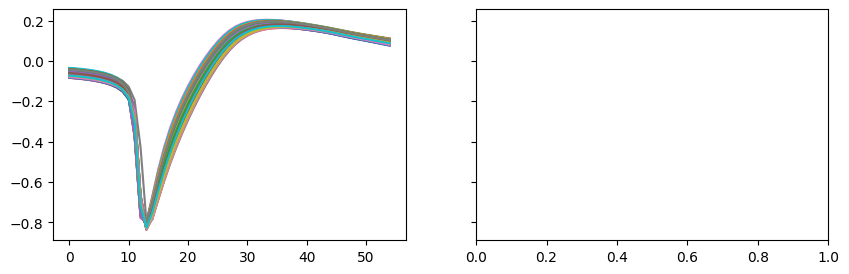

In [62]:
fig, axs = plt.subplots(1,2,figsize=(10,3),sharey=True)

offset_units = []
look_at_these = []

for probe in range(n_probes):

    probe_df = spike_df[spike_df['probe_num'] == probe]

    vm = probe_df.vm.iloc[0]
    t = probe_df.t.iloc[0]
    dt = t[1] - t[0]
    pre_spike_dur = 1.4
    duration = 5.6

    lb = pre_spike_dur
    ub = duration-pre_spike_dur

    all_peaks = find_peaks(vm, threshold=5)[0]
    all_peak_times = t[all_peaks]
    for i, peak in enumerate(all_peak_times):
        if ((peak-lb) >= t[0]) and ((peak+ub) <= t[-1]):
            peak_time = peak
            peak_shift_i = all_peaks[i]
            break

    buff = 2
    start_time = peak_time - buff
    end_time = peak_time + 2*buff

    # approximate reduced timeseries condition
    t_cond = (t >= start_time) & (t < end_time)

    # find actual maximum channel
    temp_amps = []
    try:
        for _, row in probe_df.iterrows():
            wave = row.ve[t_cond]
            amp = np.max(wave) - np.min(wave)
            temp_amps.append(amp)
    except ValueError:
        raise Exception(f'ValueError: Length of Probe = {len(probe_df)} | Peak time = {peak_time}')
    
    # actual times for aligning waveform
    temp_amps = np.array(temp_amps)
    max_channel_i = np.argmax(temp_amps)

    max_channel_ve = probe_df[probe_df['channel_num']==max_channel_i].ve.iloc[0]

    # get new extracellular spike time
    peak_time_0 = peak_time
    
    min_peak = np.argmin(max_channel_ve[t_cond])
    min_peak_time = t[min_peak+peak_shift_i-int((buff/dt))]
    
    max_peak = np.argmax(max_channel_ve[t_cond])
    max_peak_time = t[max_peak+peak_shift_i-int((buff/dt))]
    
    min_diff = np.abs(peak_time_0-min_peak_time)
    max_diff = np.abs(peak_time_0-max_peak_time)

    # take whichever is more accurate
    if min_diff<max_diff:
        peak_time = min_peak_time
        peak = min_peak
        
    else:
        peak_time = max_peak_time
        peak = max_peak

    new_t_cond = (t >= peak_time - pre_spike_dur) & (t < peak_time - pre_spike_dur + duration)

    this_peak_idx = np.argwhere(t[new_t_cond] >= peak_time)[0][0]
    this_ve = max_channel_ve[new_t_cond]
    this_ve = this_ve/np.max(temp_amps)
    if this_ve[this_peak_idx]<0:
        axs[0].plot(this_ve)
    else:
        axs[1].plot(this_ve)
        
    if this_ve[20]<-0.25:
        look_at_these.append(probe)
    

In [7]:
def find_n_closest_probes(probes, n_closest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Closest probe found at %s microns...'%np.min(distances))
    return np.argsort(distances)[:n_closest]  # np.argmin(distances)

def find_n_farthest_probes(probes, n_farthest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Farthest probe found at %s microns...'%np.max(distances))
    return np.argsort(distances)[-n_farthest:]  # np.argmax(distances)

In [8]:
closest_probes = find_n_closest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
closest_probes_df = data_df[data_df.probe_num.isin(closest_probes)]
closest_probes_df.head()

Closest probe found at 11.176532159151513 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4683155998794908e-05, 1.4683033719120108e-0...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7234130407982727e-05, 1.7234009139822218e-0...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.9768643569360802e-05, 1.9768523109521328e-0...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.229151647911385e-05, 2.2291396496642475e-05...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4816832935173393e-05, 2.4816713131216955e-0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


In [9]:
closest_probe = find_n_closest_probes(probes, 1, max_channel_i=n_channels//2)
closest_probe_df = data_df[data_df.probe_num.isin(closest_probe)]
closest_probe_df.head()

Closest probe found at 11.176532159151513 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
4352,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4557046339788114e-05, 1.455693599429246e-05...",-6.458654,-315.00852,7.634513,1147,True,408.071733,68,0
4353,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.6983757756701326e-05, 1.6983648745429887e-0...",-6.458654,-305.00852,7.634513,1147,True,408.071733,68,1
4354,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.936773590150133e-05, 1.9367627865172176e-05...",-6.458654,-295.00852,7.634513,1147,True,408.071733,68,2
4355,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.1732533931281357e-05, 2.1732426570531476e-0...",-6.458654,-285.00852,7.634513,1147,True,408.071733,68,3
4356,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4094755009214806e-05, 2.4094648088360264e-0...",-6.458654,-275.00852,7.634513,1147,True,408.071733,68,4


In [10]:
np.unique(closest_probes_df.probe_num)

array([ 0,  1,  4,  8, 10, 12, 13, 15, 17, 19, 20, 25, 26, 29, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 42, 47, 49, 51, 54, 55, 59, 62, 63, 65,
       68, 69, 70, 71, 75, 76, 78, 80, 85, 87, 89, 92, 93, 94, 97, 99])

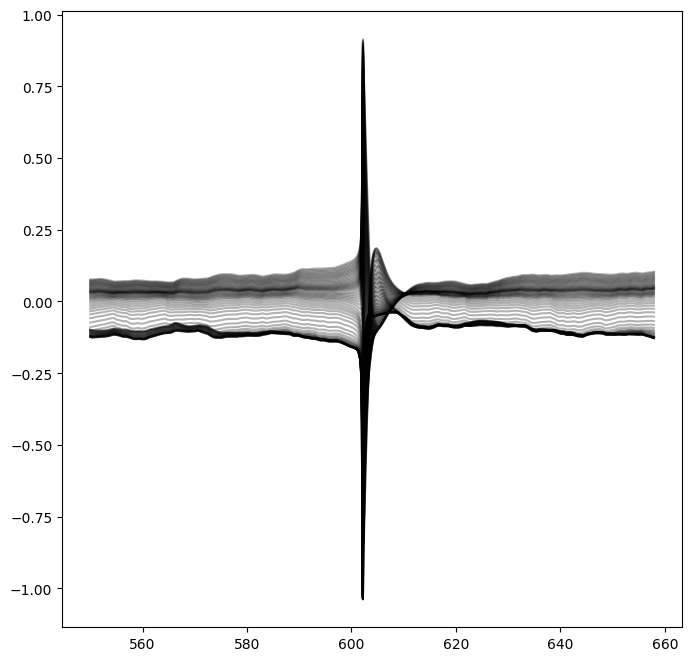

In [63]:
plt.figure(figsize=(8,8))
for _, row_df in probe_df.iterrows():
    
    t = row_df['t']
    ve = row_df['ve']
    amp = np.max(ve)-np.min(ve)

    norm_ve = np.divide(ve,amp)
    
    plt.plot(t,norm_ve,'k',alpha=0.3)
    chan_num = row_df['channel_num']

# plt.xlim(1001.5,1030)

(595.0, 610.0)

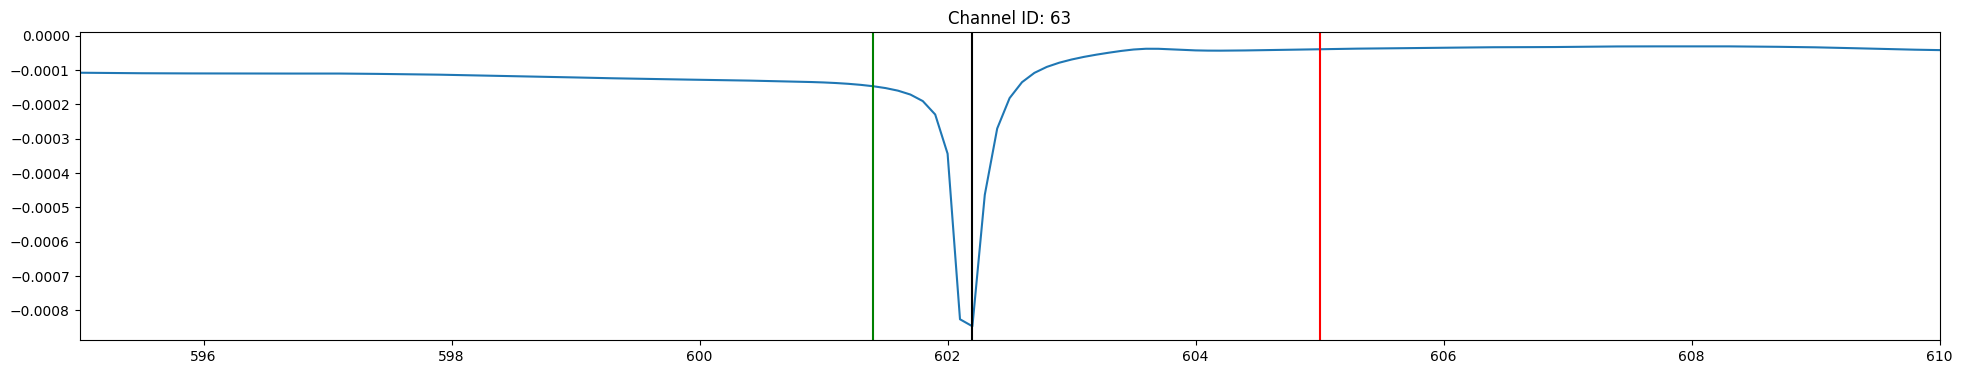

In [67]:
plt.figure(figsize=(24,4))
plt.plot(t,ve)

peak_time = t[np.argmin(ve)]

start_time = peak_time-0.8
end_time = start_time+3.6

plt.axvline(peak_time,color='k')
plt.axvline(start_time,color='g')
plt.axvline(end_time,color='r')

plt.title('Channel ID: %s'%chan_num)
plt.xlim(595,610)

In [11]:
avg_waves_close = []

for channel_num in range(num_channels):

    channel_df = closest_probes_df[closest_probes_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_close.append(channel_avg)

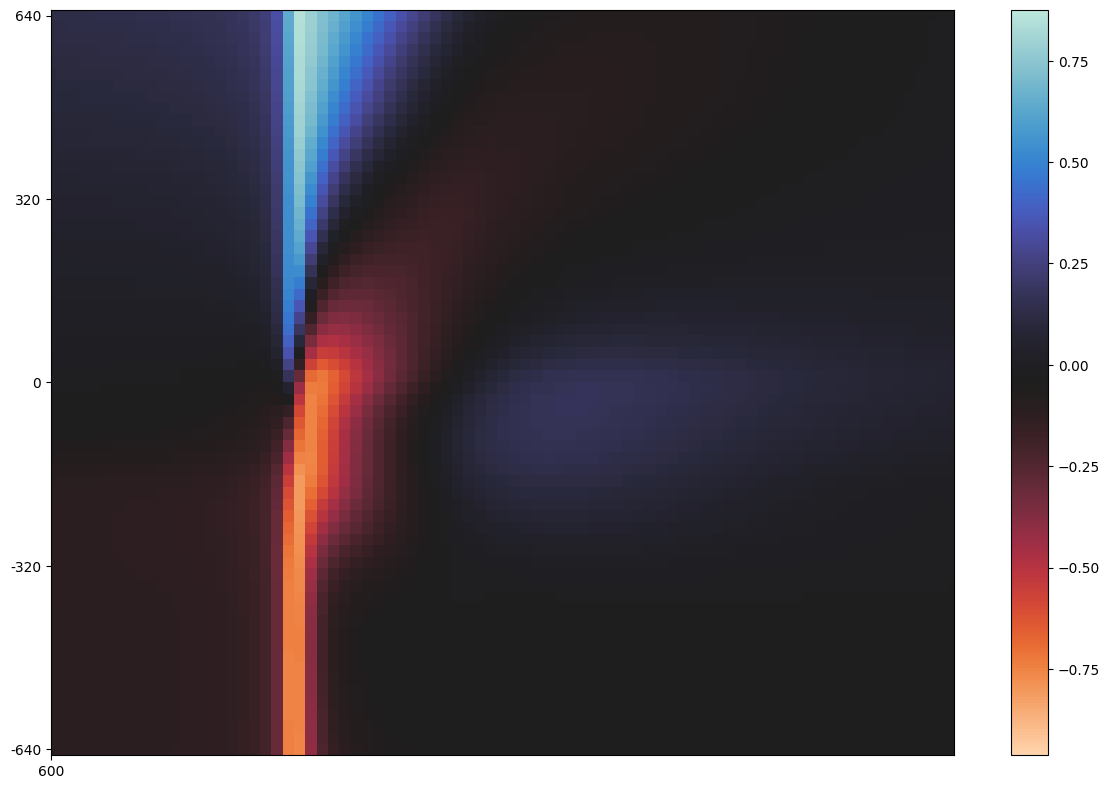

In [12]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_close, interpolation='nearest', aspect='auto', cmap=icefire_cmap, zorder=1)
# axs.plot((-center_wave*64) + (n_channels-1)/2, color='white',zorder=12)
# axs.plot((-center_wave*60)+4, color='white',zorder=12)

axs.set_xticks([1000*i for i in range(0,7)])
axs.set_xticklabels([100*i for i in range(4,11)])
axs.set_xlim([2000, 2080])
# axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticks([(n_channels-1)*i for i in [0, 0.25, 0.5, 0.75, 1]])
axs.set_yticklabels([int(n_channels*i*10) for i in [1, 0.5, 0, -0.5, -1]])
# axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'closest_probes.png'), dpi=300)

## Farthest Probes

In [13]:
farthest_probes = find_n_farthest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
farthest_probes_df = data_df[data_df.probe_num.isin(farthest_probes)]
farthest_probes_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
128,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3655621947126281e-05, 1.365550295982663e-05...",19.739821,-323.302918,14.702257,1147,True,408.071733,2,0
129,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5973996276141474e-05, 1.597387642205759e-05...",19.739821,-313.302918,14.702257,1147,True,408.071733,2,1
130,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.837185264591956e-05, 1.8371732444274937e-05...",19.739821,-303.302918,14.702257,1147,True,408.071733,2,2
131,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0825257878216612e-05, 2.0825137639752336e-0...",19.739821,-293.302918,14.702257,1147,True,408.071733,2,3
132,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.33211097541704e-05, 2.332098968637278e-05, ...",19.739821,-283.302918,14.702257,1147,True,408.071733,2,4


In [14]:
farthest_probe = find_n_farthest_probes(probes, 1, max_channel_i=n_channels//2)
farthest_probe_df = data_df[data_df.probe_num.isin(farthest_probe)]
farthest_probe_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
896,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3254017898681725e-05, 1.3253938743597239e-0...",-21.734218,-315.494051,-23.203312,1147,True,408.071733,14,0
897,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5128915093851535e-05, 1.5128836801857231e-0...",-21.734218,-305.494051,-23.203312,1147,True,408.071733,14,1
898,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7022558997414367e-05, 1.7022481722131495e-0...",-21.734218,-295.494051,-23.203312,1147,True,408.071733,14,2
899,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.8931652390301817e-05, 1.893157627939399e-05...",-21.734218,-285.494051,-23.203312,1147,True,408.071733,14,3
900,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0855571282084985e-05, 2.0855496504396556e-0...",-21.734218,-275.494051,-23.203312,1147,True,408.071733,14,4


In [15]:
np.unique(farthest_probes_df.probe_num)

array([ 2,  3,  5,  6,  7,  9, 11, 14, 16, 18, 21, 22, 23, 24, 27, 28, 30,
       41, 43, 44, 45, 46, 48, 50, 52, 53, 56, 57, 58, 60, 61, 64, 66, 67,
       72, 73, 74, 77, 79, 81, 82, 83, 84, 86, 88, 90, 91, 95, 96, 98])

In [16]:
avg_waves_far = []

for channel_num in range(num_channels):

    channel_df = farthest_probes_df[farthest_probes_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_far.append(channel_avg)

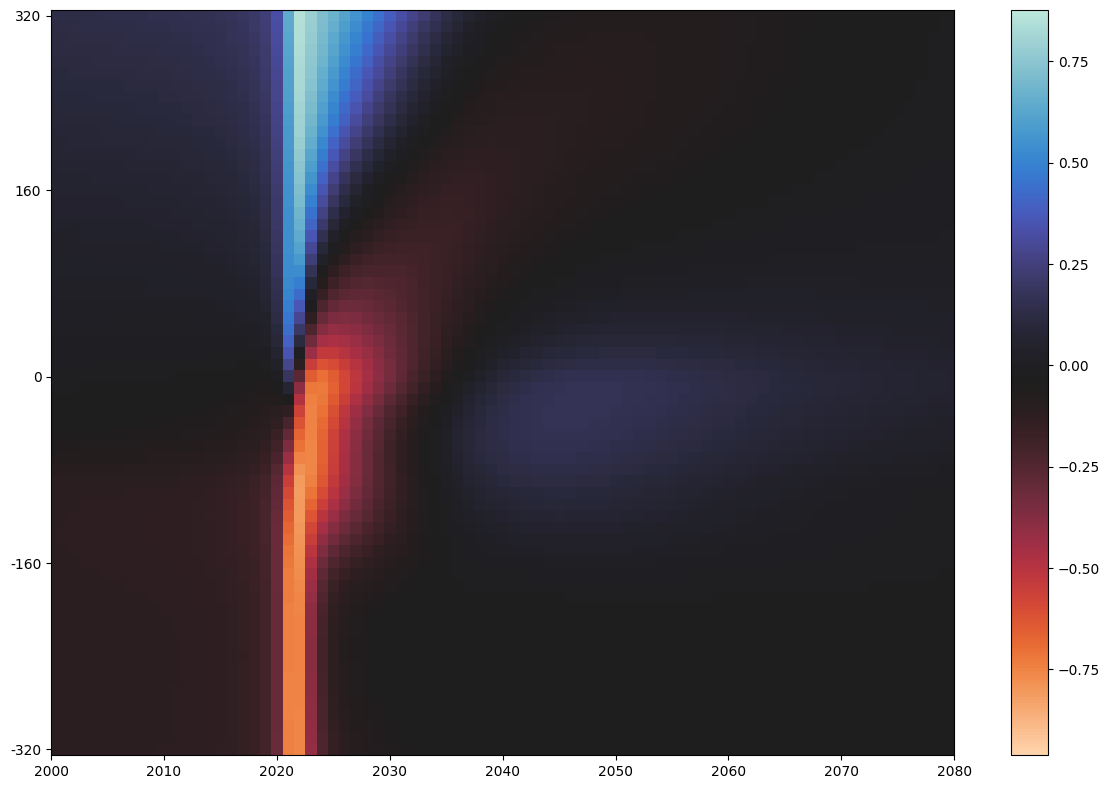

In [17]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_far, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'farthest_probes.png'), dpi=300)

### Compare farthest vs closest data

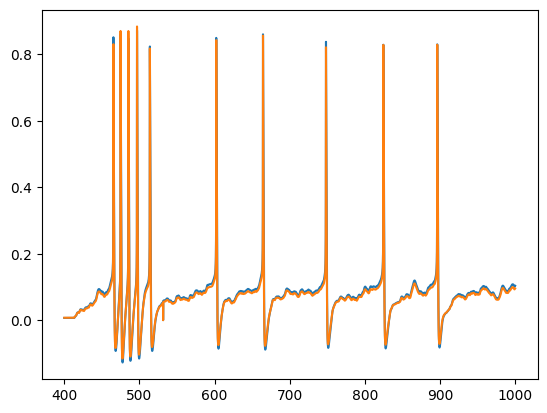

In [18]:
reduced_t = closest_probes_df.iloc[0].t[0:6000]

center_closest_ve = closest_probe_df.iloc[0].ve
norm_center_closest_ve = np.divide(center_closest_ve, np.max(center_closest_ve)-np.min(center_closest_ve))

center_farthest_ve = farthest_probe_df.iloc[0].ve
norm_center_farthest_ve = np.divide(center_farthest_ve, np.max(center_farthest_ve)-np.min(center_farthest_ve))

plt.plot(reduced_t, norm_center_closest_ve)
plt.plot(reduced_t, norm_center_farthest_ve)

In [21]:
reduced_t[2080]

608.0000000000697

### Preprocessing

In [22]:
def preprocess_probe_data(probe_df, downsample=82, resample=128, scaling_factor=20, conversion_factor=1e3, num_noisy_spikes=100):

    preprocessed_probe_df = probe_df.copy()
    new_ves = []
    all_amps = []

    t = probe_df.t.iloc[0][:-1]
    dt = t[1]-t[0]
    Fs = 1000./dt

    # find maximum channel
    temp_amps = []
    for _, row_df in probe_df.iterrows():
        wave = row_df['ve']
        amp = np.max(wave) - np.min(wave)
        temp_amps.append(amp)

    temp_amps = np.array(temp_amps)
    max_channel = np.argmax(temp_amps)

    # time for aligning waveforms
    max_chan_ve = probe_df[probe_df['channel_num'] == max_channel]['ve'].iloc[0]
    peak_time = t[np.argmin(max_chan_ve)]

    duration = 8
    start_time = 600  # peak_time-0.6
    end_time = start_time + duration

    # TODO: change start and end times
    # reduced timeseries
    t_cond = (t >= start_time) & (t < end_time)
    reduced_t = t[t_cond]

    T = len(reduced_t)

    # interpolation grid
    interp_t = np.linspace(0, duration, T)

    # downsample and upsample grids
    down_t = np.linspace(0, duration, downsample)
    if resample:
        re_t = np.linspace(0, duration, resample)
    else:
        re_t = down_t

    # global probe noise
    # corr_noise_signal = laplace.rvs(LOC, SCALE, size=len(down_t))

    # iterate over channels
    for _, row_df in probe_df.iterrows():

        # extract signal
        ve = row_df['ve']
        reduced_ve = ve[t_cond]
        
        # center and scale signal
        # mean_ve = np.median(reduced_ve, axis=0)
        # reduced_ve = conversion_factor*np.subtract(reduced_ve, mean_ve)
        reduced_ve = conversion_factor*reduced_ve

        # downsample signal
        cs = CubicSpline(interp_t, reduced_ve, axis=0)
        new_ve = cs(down_t)

        # add channel and probe noise
        # uncorr_noise_signal = laplace.rvs(LOC, SCALE, size=len(down_t))
        # if add_global_noise:
        #     noise_signal = corr_noise_signal + uncorr_noise_signal
        # else:
        #     noise_signal = uncorr_noise_signal

        # synth_ve = np.add(new_ve, noise_signal)

        # noise details
        noise_scale = 10
        noise_generator = cn.powerlaw_psd_gaussian
        p1 = 1
        p2 = (num_noisy_spikes, len(new_ve))
        args = [p1, p2]

        # add "single-trial" noise
        noise_signals = scaling_factor*noise_generator(*args)
        uncorr_noise_signal = np.mean(noise_signals, axis=0)

        synth_ve = np.add(new_ve, uncorr_noise_signal)


        # resample
        if resample:
            cs = CubicSpline(down_t, synth_ve, axis=0)
            new_ve = cs(re_t)
        else:
            new_ve = synth_ve

        # center channel
        median_ve = np.median(new_ve, axis=0)
        new_ve = np.subtract(new_ve, median_ve)

        amp = np.max(new_ve) - np.min(new_ve)

        new_ves.append(new_ve)
        all_amps.append(amp)

    preprocessed_probe_df['ve'] = new_ves
    preprocessed_probe_df['t'] = [re_t for _ in range(len(new_ves))]
    preprocessed_probe_df['amplitude'] = all_amps

    return preprocessed_probe_df, max_channel




### Closest

In [23]:
closest_probe_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
4352,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4557046339788114e-05, 1.455693599429246e-05...",-6.458654,-315.00852,7.634513,1147,True,408.071733,68,0
4353,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.6983757756701326e-05, 1.6983648745429887e-0...",-6.458654,-305.00852,7.634513,1147,True,408.071733,68,1
4354,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.936773590150133e-05, 1.9367627865172176e-05...",-6.458654,-295.00852,7.634513,1147,True,408.071733,68,2
4355,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.1732533931281357e-05, 2.1732426570531476e-0...",-6.458654,-285.00852,7.634513,1147,True,408.071733,68,3
4356,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4094755009214806e-05, 2.4094648088360264e-0...",-6.458654,-275.00852,7.634513,1147,True,408.071733,68,4


In [24]:
prep_closest_probe_df, max_close_channel = preprocess_probe_data(closest_probe_df, resample=128, scaling_factor=20, conversion_factor=1e3, num_noisy_spikes=500)
max_close_channel

35

0.39997924130592705


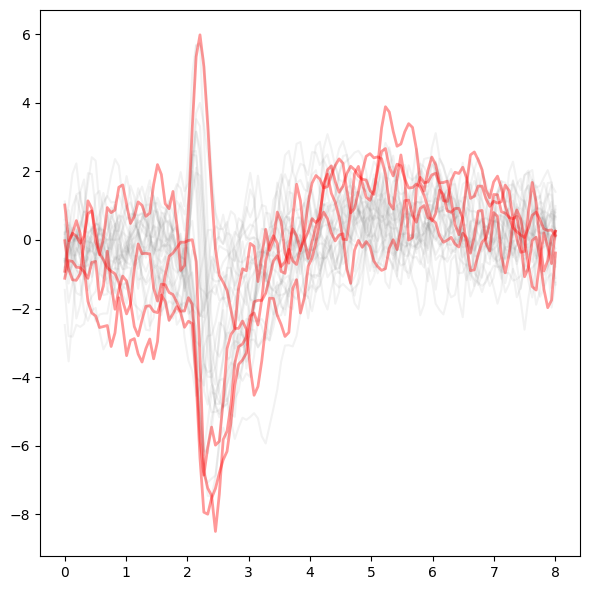

In [25]:
fig = plt.figure(figsize=(6,6))

all_amps = prep_closest_probe_df.amplitude.values
max_amp = np.max(all_amps)
max_threshold = 0.12

medians = []
    
for _, row_df in prep_closest_probe_df.iterrows():
    
    wave = row_df['ve']
    time = row_df['t']
    amp = np.max(wave)-np.min(wave)
    
    medians.append(np.median(wave))
    
    chan = row_df['channel_num']
    if chan==max_close_channel:
        c = 'C0'
        z = np.inf
        width = 4
        alpha = 1
        
        peak_to_trough_ratio = -1*np.max(wave)/np.min(wave)
    else:
        c = 'r'
        z = 1
        width = 2
        alpha = 0.4
        
#     norm_wave = np.divide(wave,amp)
    norm_wave = wave
    
    
    if (chan>=max_close_channel-15)&(chan<=max_close_channel+15):
    
        if amp>=10:#max_threshold*max_amp
            plt.plot(time,norm_wave,color=c,zorder=z,linewidth=width,alpha=alpha)

        else:
            plt.plot(time,norm_wave,zorder=0,alpha=0.1,color='gray')
        
#     plt.xlim([0,2.7])
#     plt.xlabel('Time (ms)',size='x-large')
#     plt.ylabel('Ve (normalized)',size='x-large')

plt.tight_layout()
print(peak_to_trough_ratio)   
# figname = 'example_sc_model.pdf'
# fig.savefig(figname,format='pdf')

In [31]:
prep_closest_probe_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num,amplitude
4352,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[-0.028927574853232163, -0.08755002209168428, ...",-6.458654,-315.00852,7.634513,1147,True,408.071733,68,0,5.745217
4353,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[-0.13521116870095454, 0.3045212366169354, 0.5...",-6.458654,-305.00852,7.634513,1147,True,408.071733,68,1,3.800374
4354,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4160613861303475, 0.7775296691814995, 1.031...",-6.458654,-295.00852,7.634513,1147,True,408.071733,68,2,4.185318
4355,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[-0.26512040238407053, -0.5458697115684562, 0....",-6.458654,-285.00852,7.634513,1147,True,408.071733,68,3,3.699417
4356,NMLCL000073,"[0.0, 0.02125984251968504, 0.04251968503937008...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.580778896892263, 0.8165907286637902, -0.194...",-6.458654,-275.00852,7.634513,1147,True,408.071733,68,4,3.786974


In [33]:
pre_waves_close = []

for _, row_df in prep_closest_probe_df.iterrows():

    wave = list(row_df['ve'])
    pre_waves_close.append(wave)

pre_waves_close = np.array(pre_waves_close)


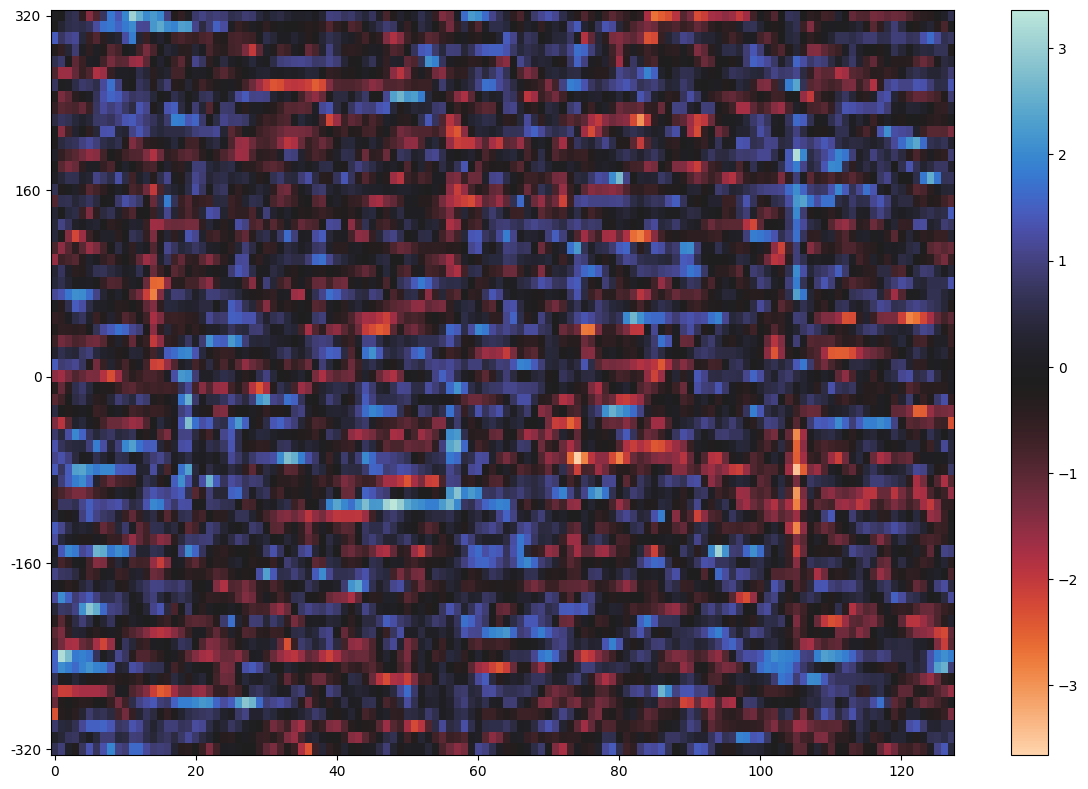

In [34]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(pre_waves_close, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
# axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
# fig.savefig(os.path.join(sim_dir, sim_label, 'farthest_probes.png'), dpi=300)